In [16]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget
from itertools import combinations
import anndata as an
import scanpy as sc
from scipy.stats import median_abs_deviation
from scipy.spatial.distance import cdist
import matplotlib.ticker as ticker
import scanpy.external as sce

import rapids_singlecell as rsc
import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)


sc.settings.verbosity = 2

# Load raw counts

In [2]:
%%time
# DGE_filtered contains only cells that meet the minimum transcript threshold (background removed)
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/pipeline_outputs/F2HS24_LIB1_GEX/all-sample/DGE_filtered"

adata = sc.read_mtx(f"{fpath}/count_matrix.mtx")
adata.obs = pd.read_csv(f"{fpath}/cell_metadata.csv")
adata.var = pd.read_csv(f"{fpath}/all_genes.csv")

# set gene ID as var index
adata.var_names = adata.var["gene_id"]
adata.var.index.name = None

# set cell barcode (i.e., bc_wells) as obs index
adata.obs_names = adata.obs['bc_wells']
adata.obs.index.name = 'cell_id'

display(adata)
display(adata.obs.head())
display(adata.var.head())

AnnData object with n_obs × n_vars = 6250 × 38606
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well'
    var: 'gene_id', 'gene_name', 'genome'

,bc_wells,sample,species,gene_count,tscp_count,mread_count,bc1_well,bc2_well,bc3_well
cell_id,,,,,,,,,
01_01_16,01_01_16,Control1_1,hg38,2760,5078,5304,A1,A1,B4
01_01_28,01_01_28,Control1_1,hg38,2832,4617,4841,A1,A1,C4
01_01_29,01_01_29,Control1_1,hg38,2886,5186,5424,A1,A1,C5
01_01_47,01_01_47,Control1_1,hg38,4529,11143,11643,A1,A1,D11
01_02_10,01_02_10,Control1_1,hg38,3557,7098,7446,A1,A2,A10


,gene_id,gene_name,genome
ENSG00000000003,ENSG00000000003,TSPAN6,hg38
ENSG00000000005,ENSG00000000005,TNMD,hg38
ENSG00000000419,ENSG00000000419,DPM1,hg38
ENSG00000000457,ENSG00000000457,SCYL3,hg38
ENSG00000000460,ENSG00000000460,C1orf112,hg38


CPU times: user 4.02 s, sys: 1.06 s, total: 5.08 s
Wall time: 5.46 s


In [8]:
# # Write out as .h5ad
# outpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas"
# adata.write_h5ad(f'{outpath}/parse_raw.h5ad')
# adata

AnnData object with n_obs × n_vars = 6250 × 38606
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well'
    var: 'gene_id', 'gene_name', 'genome'

## Barcode rank plot

In [37]:
%%time
# Load raw counts from DGE_unfiltered matrix (which contains all 'cells' and background)
fpath = "/nfs/turbo/umms-indikar/shared/projects/parse/pipeline_outputs/F2HS24_LIB1_GEX/all-sample/DGE_unfiltered"

bdata = sc.read_mtx(f"{fpath}/count_matrix.mtx")
bdata.obs = pd.read_csv(f"{fpath}/cell_metadata.csv")
bdata.var = pd.read_csv(f"{fpath}/all_genes.csv")
bdata.var_names = bdata.var["gene_id"]
bdata

CPU times: user 6.29 s, sys: 1.68 s, total: 7.97 s
Wall time: 8.19 s


AnnData object with n_obs × n_vars = 106678 × 38606
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well'
    var: 'gene_id', 'gene_name', 'genome'

In [38]:
df = bdata.obs.copy()
print(df.shape)
df.head()

# sort cells by transcript count, highest first
rank_df = (
    df[['bc_wells', 'tscp_count']]
    .dropna()
    .sort_values('tscp_count', ascending=False)
    .reset_index(drop=True)
)

# add barcode rank
rank_df['bc_rank'] = rank_df.index + 1

print(rank_df.shape)
rank_df.head()

# for the run report, we know the transcript count at the steepest point in the barcode rank plot curve = 701
steepest_tscp = 701
steepest_rank = rank_df.loc[rank_df['tscp_count'] == steepest_tscp, 'bc_rank'].iloc[0]

print(f"Steepest point rank: {steepest_rank}")
print(f"Transcript count at steepest point: {steepest_tscp}")

rank_df['color'] = np.where(
    rank_df['tscp_count'] >= steepest_tscp,
    'royalblue',
    'gainsboro'
)

rank_df.head()

(106678, 9)
(106678, 3)
Steepest point rank: 6267
Transcript count at steepest point: 701


,bc_wells,tscp_count,bc_rank,color
0,04_26_28,67069,1,royalblue
1,05_42_68,35200,2,royalblue
2,06_56_29,34073,3,royalblue
3,05_76_17,32474,4,royalblue
4,05_96_13,30600,5,royalblue


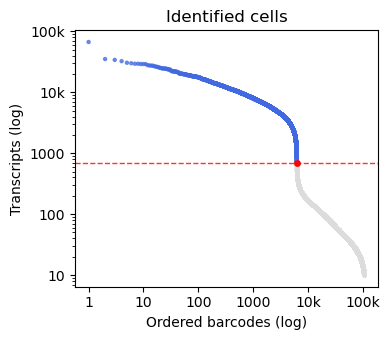

In [41]:
def log_tick_formatter(x, pos):
    """
    Format log-scale ticks as:
    1, 10, 100, 1000, 10k, 100k, 1M, etc.
    """
    if x < 1:
        return ""

    if x < 10_000:
        return f"{int(x)}"
    elif x < 1_000_000:
        return f"{int(x / 1_000)}k"
    else:
        return f"{x / 1_000_000:g}M"


plt.figure(figsize=(4, 3.5), dpi=100)

plt.scatter(
    rank_df['bc_rank'],
    rank_df['tscp_count'],
    s=10,
    alpha=0.8,
    ec='none',
    color=rank_df['color'],
)

plt.scatter(
    steepest_rank,
    steepest_tscp,
    color='red',
    s=15,
    zorder=5,
    label=f"Steepest point: {int(steepest_tscp)} transcripts"
)

# Optional horizontal threshold line
plt.axhline(
    steepest_tscp,
    color='red',
    linestyle='--',
    linewidth=1,
    alpha=0.8
)

plt.xscale('log')
plt.yscale('log')

ax = plt.gca()

# Major ticks at powers of 10
ax.xaxis.set_major_locator(ticker.LogLocator(base=10))
ax.yaxis.set_major_locator(ticker.LogLocator(base=10))

# Custom major tick labels
ax.xaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))

# Remove minor ticks from x-axis
ax.xaxis.set_minor_locator(ticker.NullLocator())

# Keep minor ticks on y-axis
ax.yaxis.set_minor_locator(
    ticker.LogLocator(base=10, subs=range(2, 10))
)
ax.yaxis.set_minor_formatter(ticker.NullFormatter())


plt.xlabel('Ordered barcodes (log)')
plt.ylabel('Transcripts (log)')
plt.title('Identified cells')

plt.tight_layout()
plt.show()

# Assign samples

In [3]:
# assign CONTROL group 
condition_map = {
    'Control1_1': 'Control',
    'Control1_2': 'Control',
    'Control2_TD': 'Control',
    'D7': 'D7',
    'D14': 'D14',
    'D21': 'D21',
}

adata.obs["condition_group"] = (adata.obs["sample"].map(condition_map))

# assign CONTROL group with D0 separate
condition_map = {
    'Control1_1': 'Control',
    'Control1_2': 'Control',
    'Control2_TD': 'D0',
    'D7': 'D7',
    'D14': 'D14',
    'D21': 'D21',
}

adata.obs["condition_group_wTD"] = (adata.obs["sample"].map(condition_map))

adata.obs["condition_group_wTD"].value_counts(sort=False)

condition_group_wTD
Control     881
D0          464
D14        2017
D21        1336
D7         1552
Name: count, dtype: int64

# QC

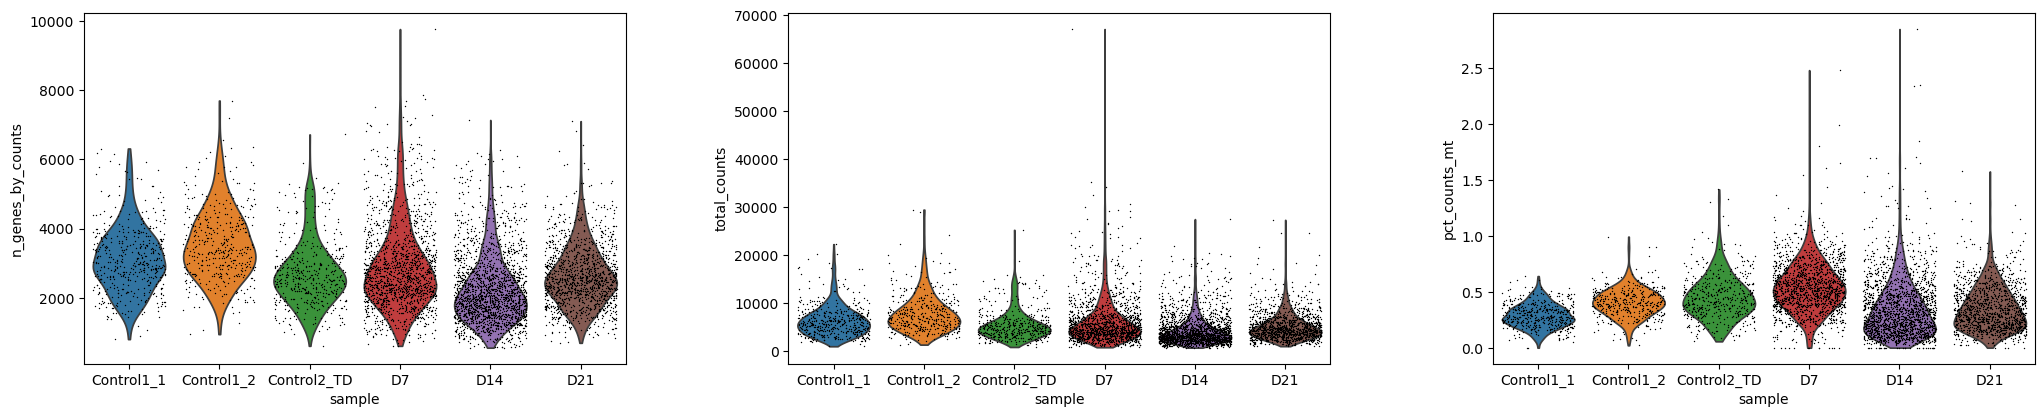

In [4]:
# mitochondrial genes
adata.var["mt"] = adata.var['gene_name'].str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var['gene_name'].str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var['gene_name'].str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

plt.rcdefaults()
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    groupby='sample',
)

(6250, 13)


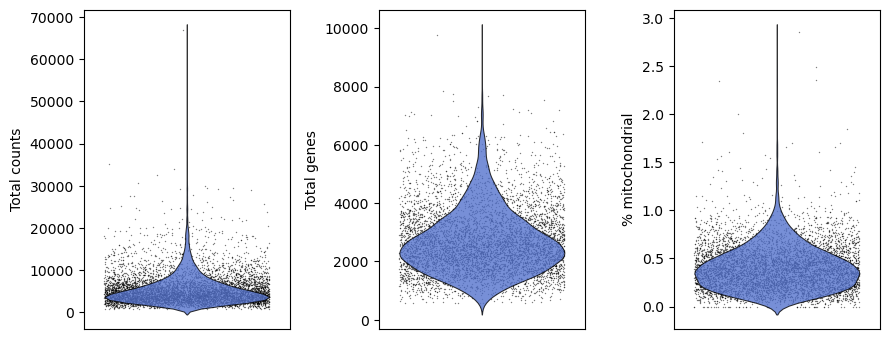

In [5]:
cols_to_keep = [
    'bc_wells', 'gene_count', 'tscp_count', 'mread_count',
    'sample', 'condition_group', 'n_genes_by_counts', 'log1p_n_genes_by_counts',
    'total_counts', 'log1p_total_counts', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb',
]

df = adata.obs[cols_to_keep].copy()
print(df.shape)


metrics = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt']

fig, axes = plt.subplots(1, len(metrics), figsize=(9, 3.5), dpi=100)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.violinplot(
        df,
        y=metric,
        linewidth=0.75,
        linecolor='k',
        color='royalblue',
        inner=None,
        alpha=0.8,
        zorder=1,
        ax=ax,
    )

    sns.stripplot(
        df,
        y=metric,
        jitter=0.4,
        color='k',
        edgecolor=None,
        size=1,
        alpha=0.5,
        zorder=0,
        ax=ax,
    )
    
    ax.tick_params(axis='x', bottom=False)


axes[0].set_ylabel('Total counts')
axes[1].set_ylabel('Total genes')
axes[2].set_ylabel('% mitochondrial')
    
plt.tight_layout()
plt.show()

# Filter cells

In [6]:
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]

    if len(M) < 2 or M.isnull().all():
        return pd.Series(False, index=adata.obs.index)

    median_val = np.median(M)
    mad_val = median_abs_deviation(M)
    print(f'{metric}:\tMedian val: {median_val}, MAD val: {mad_val}')

    if mad_val == 0:
        return pd.Series(False, index=adata.obs.index)

    outliers = (M < median_val - nmads * mad_val) | \
               (M > median_val + nmads * mad_val)

    return outliers



### determine outliers
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
)

print("Number of outlier cells based on counts:")
print(adata.obs['outlier'].sum())


adata.obs["mt_outlier"] = (
    is_outlier(adata, "pct_counts_mt", 5)
    | (adata.obs["pct_counts_mt"] > 20)
)

print("\nNumber of outlier cells based on pct mito:")
print(adata.obs['mt_outlier'].sum())


init_cells = adata.n_obs
print(f"Total number of cells: {init_cells}")

print("\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs

print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"\nTotal cells after filtering of low quality cells: {final_cells}")

adata

log1p_total_counts:	Median val: 8.409162521362305, MAD val: 0.3827223777770996
log1p_n_genes_by_counts:	Median val: 7.829630389150193, MAD val: 0.2648733762444637
Number of outlier cells based on counts:
22
pct_counts_mt:	Median val: 0.3762172758579254, MAD val: 0.1476011574268341

Number of outlier cells based on pct mito:
59
Total number of cells: 6250

Filtering...

Removed 78 total cells.

Total cells after filtering of low quality cells: 6172


AnnData object with n_obs × n_vars = 6172 × 38606
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sample_colors'

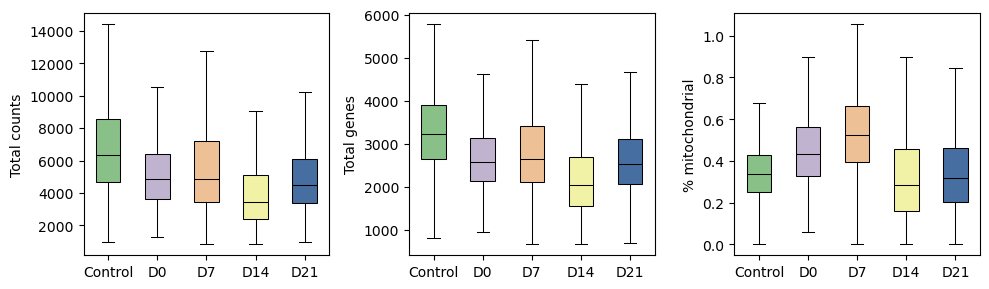

In [7]:
metrics = ['total_counts', 'n_genes_by_counts', 'pct_counts_mt']

fig, axes = plt.subplots(1, len(metrics), figsize=(10, 3), dpi=100)

for i, metric in enumerate(metrics):
    ax = axes[i]
    
    sns.boxplot(
        adata.obs,
        x='condition_group_wTD',
        y=metric,
        linewidth=0.75,
        linecolor='k',
        hue='condition_group_wTD',
        palette='Accent',
        width=0.5,
        ax=ax,
        showfliers=False,
    )

    ax.set_xlabel('')


axes[0].set_ylabel('Total counts')
axes[1].set_ylabel('Total genes')
axes[2].set_ylabel('% mitochondrial')
    
plt.tight_layout()
plt.show()

,condition_group_wTD,cell_count
0,Control,881
1,D0,459
2,D7,1529
3,D14,1974
4,D21,1329


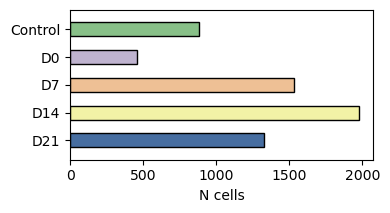

In [8]:
# final cell counts
counts = pd.DataFrame({
    'cell_id': adata.obs['bc_wells'].values,
    'condition': adata.obs['sample'].values,
    'condition_group_wTD': adata.obs['condition_group_wTD'].values,
})

grouping_col = 'condition_group_wTD'

if grouping_col == 'condition_group_wTD':
    palette='Accent'
    order=['Control', 'D0', 'D7', 'D14', 'D21']
else:
    palette='tab10'

pool_df = counts.groupby(grouping_col, observed=True).size().reset_index(name='cell_count')
display(pool_df)

plt.figure(figsize=(4,2.23), dpi=100)

sns.barplot(
    pool_df,
    x='cell_count',
    y=grouping_col,
    hue=grouping_col,
    order=order,
    hue_order=order,
    palette=palette,
    width=0.5,
    ec='k',
)

plt.xlabel("N cells")
plt.ylabel("")

plt.gca().margins(y=0.1)

plt.tight_layout()
plt.show()

## Check D14

In [17]:
from scipy import stats
from scipy.stats import shapiro, levene, kruskal, mannwhitneyu
import scikit_posthocs as sp
from statsmodels.stats.multitest import multipletests

def normality_check(df, col='total_counts', group_col='condition_group_wTD', alpha=0.05):
    
    groups = df[group_col].unique()
    
    for group in groups:
        
        lfc = df[df[group_col] == group][col]
        
        stat1, p1 = stats.shapiro(lfc) # Shapiro-Wilk test
        stat2, p2 = stats.normaltest(lfc) # D’Agostino and Pearson’s test
        
        if p1 < alpha:
            sig1 = 'SIG (data is NOT normal)'
        else:
            sig1 = 'NOT SIG (data is normal)'
            
        if p2 < alpha:
            sig2 = 'SIG (data is NOT normal)'
        else:
            sig2 = 'NOT SIG (data is normal)'
        
        print(f'{group}:\tShapiro-Wilk p-val = {p1:.4e} {sig1},\tD’Agostino and Pearson’s p-val = {p2:.4e} {sig2}')

In [16]:
df = adata.obs[['total_counts', 'n_genes_by_counts', 'condition_group_wTD']].copy()
display(df.head())

normality_check(df, 'total_counts', 'condition_group_wTD')

,total_counts,n_genes_by_counts,condition_group_wTD
cell_id,,,
01_01_16,5078.0,2760,Control
01_01_28,4617.0,2832,Control
01_01_29,5186.0,2886,Control
01_01_47,11143.0,4529,Control
01_02_10,7098.0,3557,Control


Control:	Shapiro-Wilk p-val = 2.8618e-25 SIG (data is NOT normal),	D’Agostino and Pearson’s p-val = 0.0000e+00 SIG (data is NOT normal)
D0:	Shapiro-Wilk p-val = 2.3918e-21 SIG (data is NOT normal),	D’Agostino and Pearson’s p-val = 3.0829e-44 SIG (data is NOT normal)
D14:	Shapiro-Wilk p-val = 3.9521e-45 SIG (data is NOT normal),	D’Agostino and Pearson’s p-val = 0.0000e+00 SIG (data is NOT normal)
D21:	Shapiro-Wilk p-val = 7.2950e-35 SIG (data is NOT normal),	D’Agostino and Pearson’s p-val = 0.0000e+00 SIG (data is NOT normal)
D7:	Shapiro-Wilk p-val = 1.4497e-40 SIG (data is NOT normal),	D’Agostino and Pearson’s p-val = 0.0000e+00 SIG (data is NOT normal)


In [20]:
def kruskal_dunn_test(df, metric, group_col="condition_group_wTD", alpha=0.05):
    """Kruskal-Wallis test + Dunn's post hoc (Holm-corrected) if significant."""
    print(metric)
    tmp = df[[metric, group_col]].dropna()

    # Overall test across all groups
    groups = [g[metric].values for _, g in tmp.groupby(group_col, observed=True)]
    H, p = kruskal(*groups)
    print(f"Kruskal-Wallis: H={H:.3f}, p={p:.4e}")

    if p >= alpha:
        return None

    # Pairwise post hoc test
    print("\nDunn's post hoc (Holm corrected):")
    dunn = sp.posthoc_dunn(tmp, val_col=metric, group_col=group_col, p_adjust="holm")
    # print(dunn)

    # Reshape to long format, keep significant pairs
    sig = (
        dunn.stack()
        .reset_index()
        .rename(columns={"level_0": "Group1", "level_1": "Group2", 0: "adjusted_p"})
    )
    sig[["Group1", "Group2"]] = sig[["Group1", "Group2"]].astype(str)
    sig = sig[sig["adjusted_p"] < alpha].copy()

    # Annotate direction of effect using group medians
    medians = df.groupby(group_col, observed=True)[metric].median()
    sig["median_1"] = sig["Group1"].map(medians)
    sig["median_2"] = sig["Group2"].map(medians)
    sig["direction"] = np.where(
        sig["median_1"] < sig["median_2"], "Group1 < Group2", "Group1 > Group2"
    )
    return sig


for metric in ["total_counts", "n_genes_by_counts"]:
    sig = kruskal_dunn_test(df, metric)
    if sig is not None:
        display(sig)

total_counts
Kruskal-Wallis: H=685.116, p=5.8210e-147

Dunn's post hoc (Holm corrected):


,Group1,Group2,adjusted_p,median_1,median_2,direction
1,Control,D0,2.997904e-15,6347.0,4834.0,Group1 > Group2
2,Control,D7,2.377819e-24,6347.0,4855.0,Group1 > Group2
3,Control,D14,4.410051e-134,6347.0,3448.0,Group1 > Group2
4,Control,D21,4.125402e-42,6347.0,4464.0,Group1 > Group2
5,D0,Control,2.997904e-15,4834.0,6347.0,Group1 < Group2
8,D0,D14,1.745342e-24,4834.0,3448.0,Group1 > Group2
9,D0,D21,2.770805e-02,4834.0,4464.0,Group1 > Group2
10,D7,Control,2.377819e-24,4855.0,6347.0,Group1 < Group2
13,D7,D14,8.236830e-61,4855.0,3448.0,Group1 > Group2
14,D7,D21,5.908420e-05,4855.0,4464.0,Group1 > Group2


n_genes_by_counts
Kruskal-Wallis: H=799.896, p=8.0881e-172

Dunn's post hoc (Holm corrected):


,Group1,Group2,adjusted_p,median_1,median_2,direction
1,Control,D0,3.019653e-21,3228.0,2582.0,Group1 > Group2
2,Control,D7,1.078774e-29,3228.0,2656.0,Group1 > Group2
3,Control,D14,2.696722e-158,3228.0,2051.5,Group1 > Group2
4,Control,D21,7.968099e-47,3228.0,2530.0,Group1 > Group2
5,D0,Control,3.019653e-21,2582.0,3228.0,Group1 < Group2
8,D0,D14,1.963110e-24,2582.0,2051.5,Group1 > Group2
10,D7,Control,1.078774e-29,2656.0,3228.0,Group1 < Group2
13,D7,D14,1.896122e-69,2656.0,2051.5,Group1 > Group2
14,D7,D21,3.223597e-04,2656.0,2530.0,Group1 > Group2
15,D14,Control,2.696722e-158,2051.5,3228.0,Group1 < Group2


In [21]:
# One-sided test: is `target` group lower than all others combined, per metric?
target = "D14"
results = []
for metric in ["total_counts", "n_genes_by_counts"]:
    x = df.loc[df["condition_group_wTD"] == target, metric]
    others = df.loc[df["condition_group_wTD"] != target, metric]
    stat, p = mannwhitneyu(x, others, alternative="less")
    results.append((metric, stat, p))

res_df = pd.DataFrame(results, columns=["metric", "stat", "p"])
res_df["p_adj"] = multipletests(res_df["p"], method="fdr_bh")[1]
res_df["significant"] = res_df["p_adj"] < 0.05
display(res_df)

,metric,stat,p,p_adj,significant
0,total_counts,2700519.0,1.591729e-108,1.591729e-108,True
1,n_genes_by_counts,2581718.0,9.658528e-127,1.931706e-126,True


# Gene filtering and normalization

In [9]:
# keep full dimension safe
adata.raw = adata  

# save raw counts
adata.layers['raw_counts'] = adata.X.copy()


print("Filtering genes...\n")
sc.pp.filter_genes(adata, min_counts=10)

print("\nNormalizing counts to 10,000...\n")
sc.pp.normalize_total(
    adata,
    target_sum=1e4,
)

# log transform normalized counts
sc.pp.log1p(adata)

# save log normalized counts
adata.layers['log_norm'] = adata.X.copy()

adata

Filtering genes...

filtered out 19909 genes that are detected in less than 10 counts

Normalizing counts to 10,000...

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts'
    uns: 'sample_colors', 'log1p'
    layers: 'raw_counts', 'log_norm'

# HVGs and PCA

extracting highly variable genes
Number of HVG: 2000


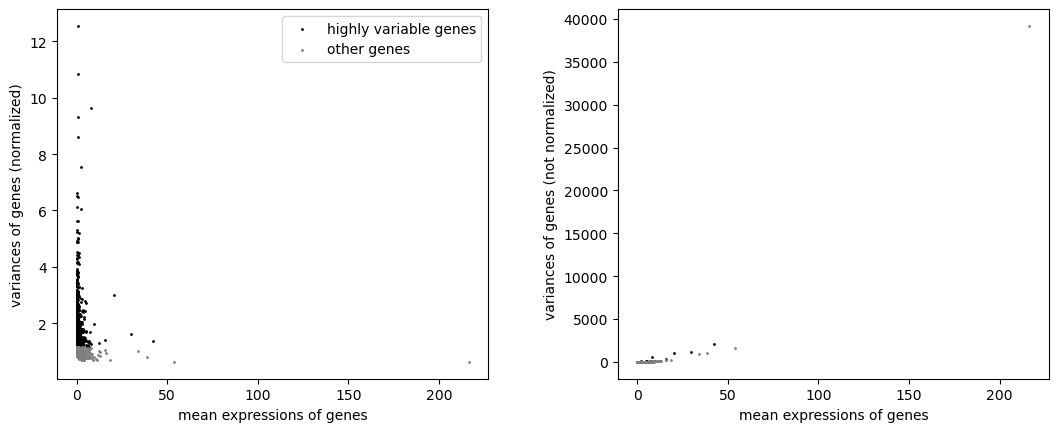

computing PCA
    with n_comps=50
    finished (0:00:01)


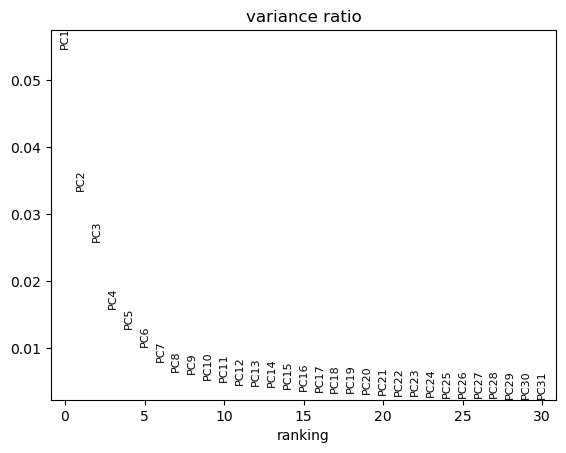

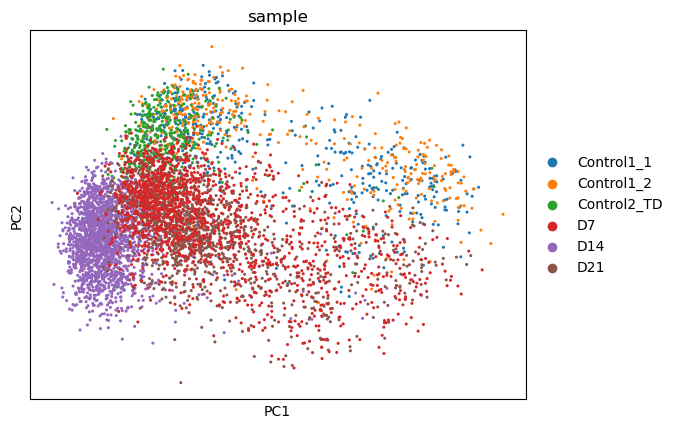

AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'sample_colors', 'log1p', 'hvg', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    la

In [10]:
### HVGs
adata.X = adata.layers['raw_counts'].copy()

sc.pp.highly_variable_genes(
    adata,
    flavor='seurat_v3',
)

print(f"Number of HVG: {adata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(adata)

adata.X = adata.layers['log_norm'].copy()

### PCA
sc.pp.pca(adata)

plt.rcdefaults()
sc.pl.pca_variance_ratio(adata)
sc.pl.pca(adata, color='sample')

adata

In [11]:
# Make gene names var_names
adata.var_names = adata.var['gene_name'].astype(str)
adata.var_names_make_unique()
adata.var.head()

,gene_id,gene_name,genome,mt,ribo,hb,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts,n_counts,highly_variable,highly_variable_rank,means,variances,variances_norm
gene_name,,,,,,,,,,,,,,,,,,
TSPAN6,ENSG00000000003,TSPAN6,hg38,False,False,False,477,0.08448,0.081101,92.368,528.0,6.270988,523.0,False,NaN,0.084738,0.095719,0.988727
DPM1,ENSG00000000419,DPM1,hg38,False,False,False,1254,0.24560,0.219617,79.936,1535.0,7.336937,1513.0,False,NaN,0.245139,0.292352,0.943234
SCYL3,ENSG00000000457,SCYL3,hg38,False,False,False,614,0.10528,0.100099,90.176,658.0,6.490724,651.0,False,NaN,0.105476,0.110247,0.904822
C1orf112,ENSG00000000460,C1orf112,hg38,False,False,False,459,0.08640,0.082869,92.656,540.0,6.293419,538.0,False,NaN,0.087168,0.109723,1.100347
CFH,ENSG00000000971,CFH,hg38,False,False,False,2489,0.68864,0.523923,60.176,4304.0,8.367533,4275.0,True,1220.0,0.692644,1.375457,1.272217


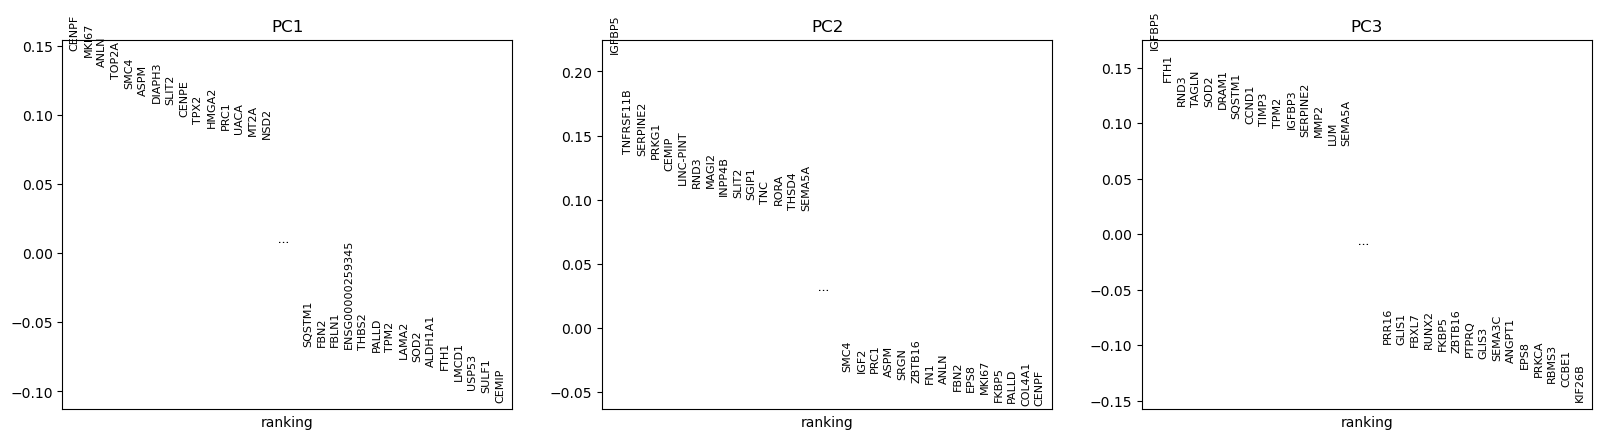

In [12]:
sc.pl.pca_loadings(adata)

# Predict cell cycle phase

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:00)
computing score 'G2M_score'
    finished (0:00:00)


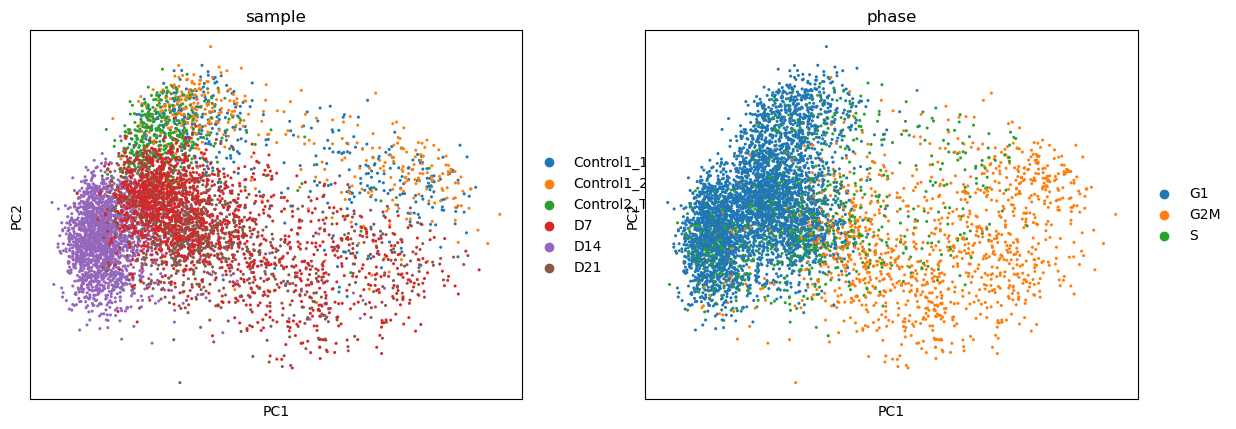

CPU times: user 890 ms, sys: 378 ms, total: 1.27 s
Wall time: 1.29 s


In [13]:
%%time
regev_genes = [x.strip() for x in open('../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
    layer='log_norm',
)

sc.pl.pca(adata, color=['sample', 'phase'])

# UMAP

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:06)
computing UMAP
    finished (0:00:23)
running Leiden clustering
    finished (0:00:00)


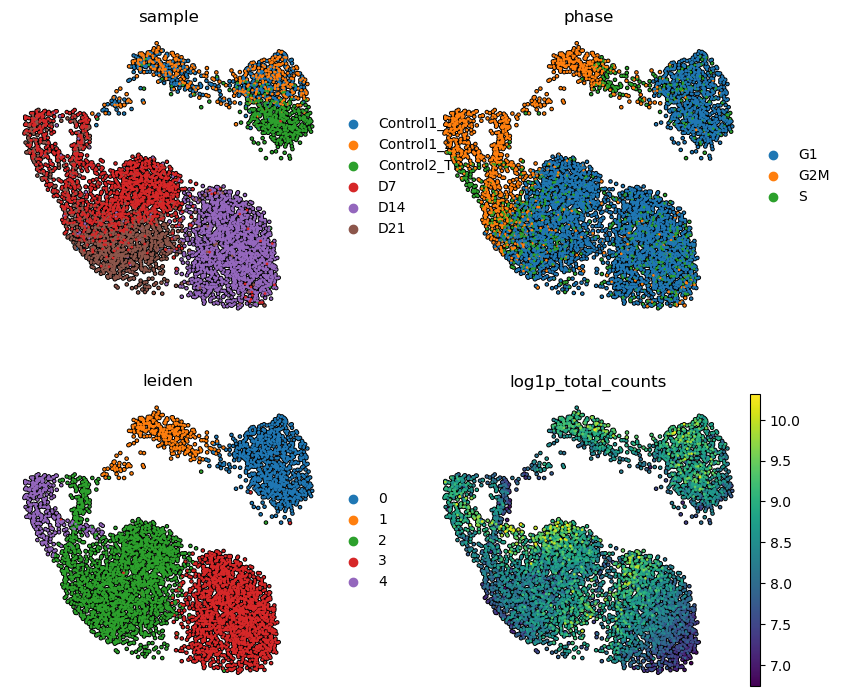

In [14]:
sc.pp.neighbors(adata, n_neighbors=45)

sc.tl.umap(adata)

sc.tl.leiden(
    adata,
    resolution=0.4,
    flavor='igraph',
)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['sample', 'phase', 'leiden', 'log1p_total_counts'],
    size=15,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Harmony

2026-08-06 17:32:22,273 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-08-06 17:32:23,648 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-08-06 17:32:23,678 - harmonypy - INFO - Iteration 1 of 10
2026-08-06 17:32:24,744 - harmonypy - INFO - Iteration 2 of 10
2026-08-06 17:32:25,872 - harmonypy - INFO - Converged after 2 iterations


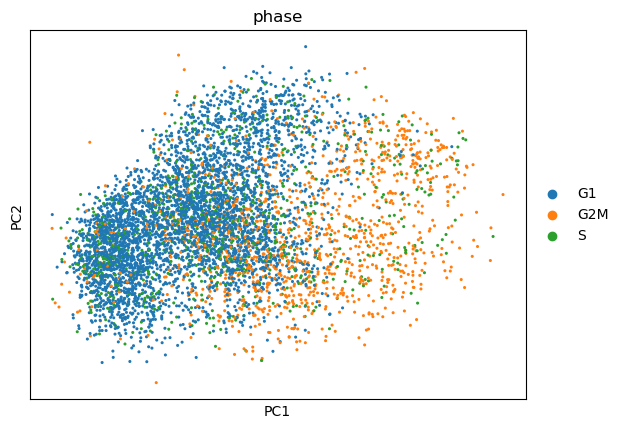

In [15]:
# remove cell cycle effect
bdata = adata.copy()

### Harmony integration
sce.pp.harmony_integrate(bdata, key='phase')

# Save original PCA space
bdata.obsm["X_pca_original"] = bdata.obsm["X_pca"].copy()

# Set Harmony-corrected PCA as the default for plotting
bdata.obsm["X_pca"] = bdata.obsm["X_pca_harmony"].copy()

plt.rcdefaults()
sc.pl.pca(bdata, color='phase')

running Leiden clustering
    finished (0:00:00)


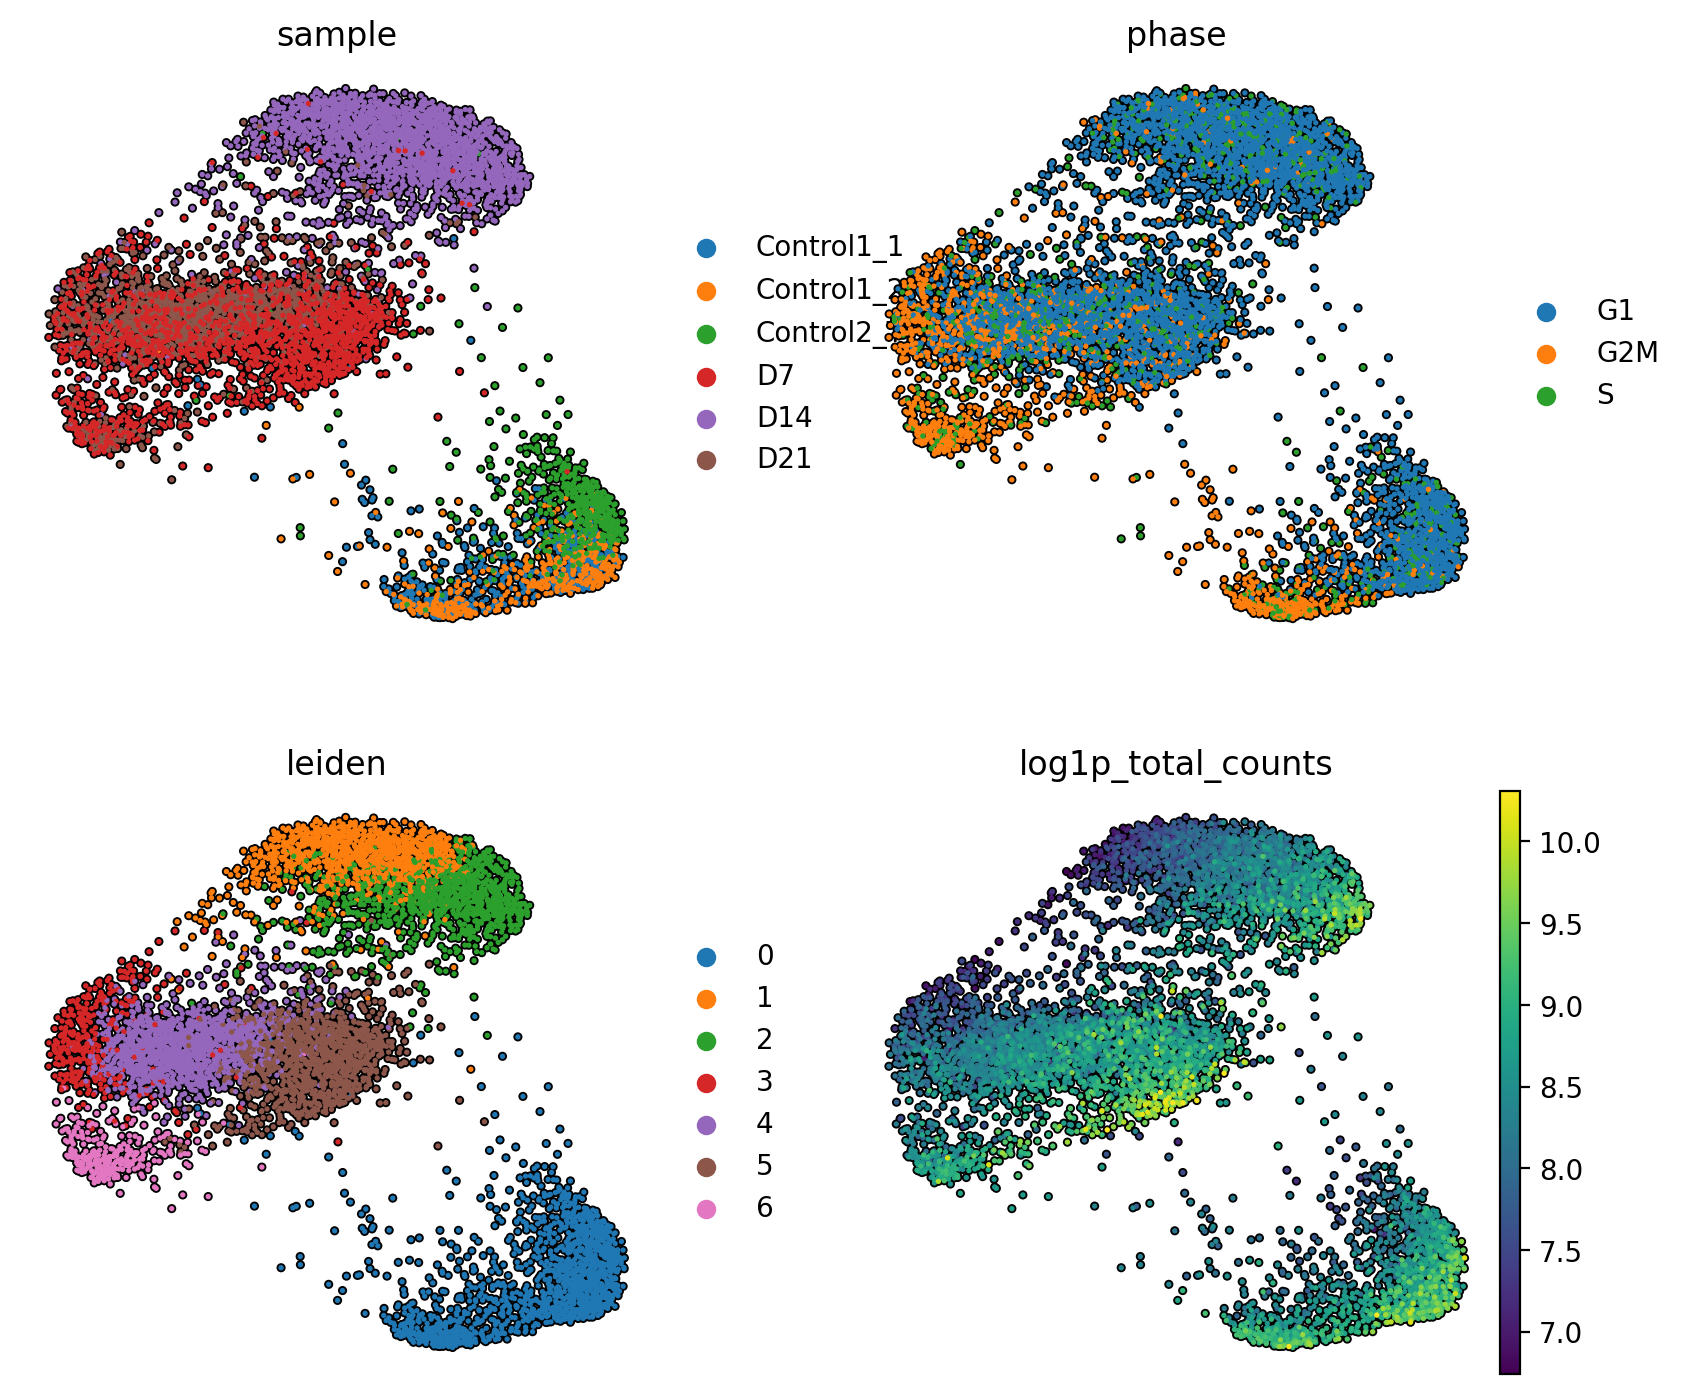

In [17]:
rsc.get.anndata_to_GPU(bdata)

rsc.pp.neighbors(
    bdata,
    use_rep='X_pca_harmony',
    n_neighbors=45,
    n_pcs=25,
)

rsc.tl.draw_graph(bdata)


rsc.get.anndata_to_CPU(bdata)

sc.tl.leiden(
    bdata,
    resolution=0.82, # 0.85 splits D14
    flavor='igraph',
)

plt.rcdefaults()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata,
    color=['sample', 'phase', 'leiden', 'log1p_total_counts'],
    size=15,
    ncols=2,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [18]:
bdata.obs['cluster_str'] = bdata.obs['leiden'].apply(lambda x: f"C{str(int(x) + 1)}")

bdata.obs['cluster_str'].value_counts()

cluster_str
C1    1328
C5    1253
C6    1048
C3     976
C2     968
C4     330
C7     269
Name: count, dtype: int64

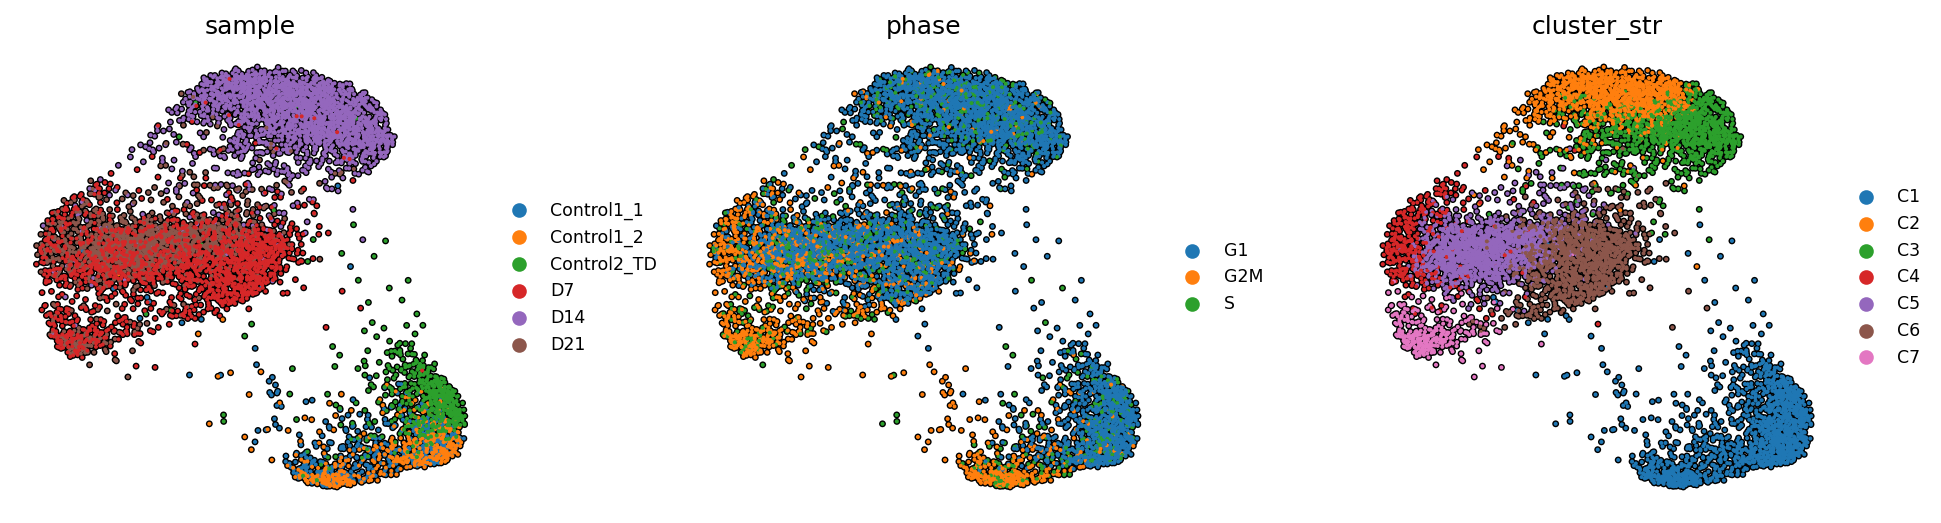

In [19]:
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.draw_graph(
    bdata,
    color=['sample', 'phase', 'cluster_str'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
    legend_fontsize='small',
    wspace=0.3,
)

In [20]:
bdata

AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'sample_colors', 'log

# Write out

In [21]:
%%time

bdata.var.index.name = None # for saving

outpath = "/nfs/turbo/umms-indikar/shared/projects/parse/anndatas"
bdata.write_h5ad(f'{outpath}/parse_processed.h5ad')
bdata

CPU times: user 365 ms, sys: 531 ms, total: 895 ms
Wall time: 3.77 s


AnnData object with n_obs × n_vars = 6172 × 18697
    obs: 'bc_wells', 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_well', 'bc2_well', 'bc3_well', 'condition_group', 'condition_group_wTD', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str'
    var: 'gene_id', 'gene_name', 'genome', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'sample_colors', 'log

In [ ]:
# Note: there are 2 processed h5ad files. 
# * The one saved here (parse_processed.h5ad) reflects the most recent pipeline output for all conditions (included per-condition pipeline runs)
# * parse_processed_v1.h5ad reflects the original pipeline output, in which conditions were not run separately
# * Files are highly concordant (see Hematokytos/figure3/timeseries_additional/pipeline_compare.ipynb)